# RQ1 - Clones (non-agentic vs agentic)

## Preparing data

In [ ]:
#!pip install ijson

### Creating parquet file for faster access

In [1]:
from pathlib import Path
import pandas as pd
import ijson

RESULTS_DIR = Path("../../results")
PARQUET_FILE = RESULTS_DIR/"results.parquet"

if PARQUET_FILE.exists():
    print(f"Loading existing {PARQUET_FILE.name}...")
    df = pd.read_parquet(PARQUET_FILE)

else:
    print("Creating Parquet file...")

    chunks = []

    for file in RESULTS_DIR.glob("*_detailed_results.json"):

        print(f"Processing {file.name}")

        prefix = int(file.name.split("_")[0])

        project = "_".join(file.stem.split("_")[1:-2])

        rows = []

        with open(file, "rb") as f:
            for item in ijson.items(f, "item"):

                rows.append({
                    "file": file.name,
                    "file_index": prefix,
                    "agentic": prefix % 2 == 1,
                    "base_index": prefix - 1 if prefix % 2 else prefix,
                    "project": project,
                    "model": item["model"],
                    "language": item["language"],
                    "sim": item["sim"],
                    "codebleu": item["codebleu"],
                })

        chunks.append(pd.DataFrame(rows))

    df = pd.concat(chunks, ignore_index=True)

    df.to_parquet(PARQUET_FILE, index=False)

    print(f"Saved to {PARQUET_FILE}")

print(df.shape)
df.head()

Creating Parquet file...
Processing 0000_codespecs_daikon_05f3ce2b80a0_detailed_results.json
Processing 0001_codespecs_daikon_9248a320cff0_detailed_results.json
Processing 0002_talsma-ict_umldoclet_7d9c23724747_detailed_results.json
Processing 0003_talsma-ict_umldoclet_a45be18a2f81_detailed_results.json
Processing 0004_hazendaz_displaytag_a48cd64d7466_detailed_results.json
Processing 0005_hazendaz_displaytag_45fef5f8b4bf_detailed_results.json
Processing 0006_cryptomator_cryptofs_0def3661ef8c_detailed_results.json
Processing 0007_cryptomator_cryptofs_98ece9cc4257_detailed_results.json
Processing 0008_bndtools_bnd_7aaf1c3f16ed_detailed_results.json
Processing 0009_bndtools_bnd_7e0fad3f069a_detailed_results.json
Processing 0010_typetools_checker-framework_8e008df6409c_detailed_results.json
Processing 0011_typetools_checker-framework_8eb4b4f264dc_detailed_results.json
Processing 0012_alibaba_druid_50e3af6f9081_detailed_results.json
Processing 0013_alibaba_druid_c9f4d9d194af_detailed_result

,file,file_index,agentic,base_index,project,model,language,sim,codebleu
0,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,1.0,1.0
1,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,1.0,1.0
2,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,0.09006833285093307,0.2713110220678924
3,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,0.09006833285093307,0.2713110220678924
4,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,0.08340410888195038,0.25880670718429144


## Compare distributions

In [3]:
df.groupby("agentic")[["sim", "codebleu"]].mean()

,sim,codebleu
agentic,,
False,0.575282,0.41902
True,0.627048,0.501535


## Boxplots

### Semantic/Syntactic similarity

C:\Users\lamp6\AppData\Local\Temp\ipykernel_17380\691957160.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
C:\Users\lamp6\AppData\Local\Temp\ipykernel_17380\691957160.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


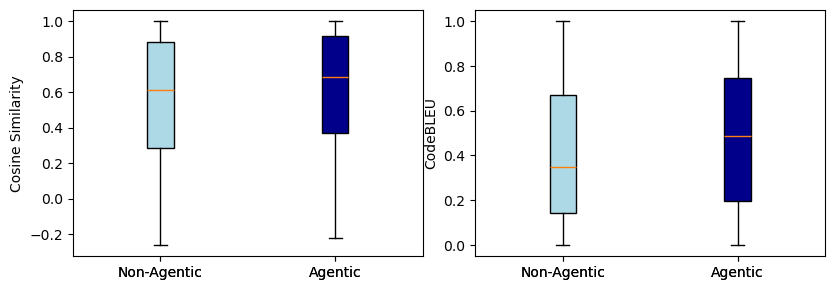

In [21]:
import matplotlib.pyplot as plt

# Ensure numeric values
df["sim"] = pd.to_numeric(df["sim"], errors="coerce")
df["codebleu"] = pd.to_numeric(df["codebleu"], errors="coerce")

# Prepare data
sim_false = df[df["agentic"] == False]["sim"].dropna()
sim_true = df[df["agentic"] == True]["sim"].dropna()

codebleu_false = df[df["agentic"] == False]["codebleu"].dropna()
codebleu_true = df[df["agentic"] == True]["codebleu"].dropna()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 3.2),   # smaller width and height
    sharex=True
)

colors = ["lightblue", "darkblue"]

# Similarity boxplot
bp1 = axes[0].boxplot(
    [sim_false, sim_true],
    labels=["Non-Agentic", "Agentic"],
    patch_artist=True
)

axes[0].set_ylabel("Cosine Similarity")

for patch, color in zip(bp1["boxes"], colors):
    patch.set_facecolor(color)


# CodeBLEU boxplot
bp2 = axes[1].boxplot(
    [codebleu_false, codebleu_true],
    labels=["Non-Agentic", "Agentic"],
    patch_artist=True
)

axes[1].set_ylabel("CodeBLEU")

for patch, color in zip(bp2["boxes"], colors):
    patch.set_facecolor(color)


#  spacing between plots
plt.subplots_adjust(
    wspace=0.15,   # horizontal spacing
    left=0.04,
    right=0.98,
    bottom=0.18,
    top=0.95
)

plt.savefig(
    "plots/similarity_comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

## Paired comparison

In [6]:
df[["sim", "codebleu"]].isna().sum()

sim         0
codebleu    0
dtype: int64

In [7]:
project_scores = (
    df
    .groupby(
        [
            "project",
            "base_index",
            "agentic"
        ]
    )[["sim", "codebleu"]]
    .mean()
    .reset_index()
)

display(project_scores.head())

,project,base_index,agentic,sim,codebleu
0,aio-libs_aiohttp_97eae1940e47,66,True,0.477585,0.227804
1,aio-libs_aiohttp_eda8114ae124,66,False,0.455107,0.215197
2,alibaba_druid_50e3af6f9081,12,False,0.657736,0.443483
3,alibaba_druid_c9f4d9d194af,12,True,0.655214,0.440024
4,beast-dev_beast-mcmc_1ccf63950696,14,True,0.538378,0.366428


In [13]:
import re

def normalize_project(name):
    # remove the final hash part
    return re.sub(r'_[0-9a-f]{12}$', '', name)

df["project_group"] = df["project"].apply(normalize_project)

In [14]:
project_scores = (
    df
    .groupby(
        [
            "project_group",
            "base_index",
            "agentic"
        ]
    )[["sim", "codebleu"]]
    .mean()
    .reset_index()
)


comparison = project_scores.pivot_table(
    index=["project_group", "base_index"],
    columns="agentic",
    values=["sim", "codebleu"]
)

display(comparison.head(10))

codebleu            \
agentic                                                  False     True    
project_group                             base_index                       
aio-libs_aiohttp                          66          0.215197  0.227804   
alibaba_druid                             12          0.443483  0.440024   
beast-dev_beast-mcmc                      14          0.368574  0.366428   
bndtools_bnd                              8           0.225645  0.223785   
cloudera_hue                              62          0.244635  0.467592   
codespecs_daikon                          0           0.341716  0.340631   
cryptomator_cryptofs                      6           0.193631  0.193927   
django-helpdesk_django-helpdesk           64          0.134486  0.141508   
django-import-export_django-import-export 58          0.145026  0.153159   
google_flax                               32          0.140781  0.169279   

                                                           sim            
agentic                                                  False     True   
project_group                             base_index                      
aio-libs_aiohttp                          66          0.455107  0.477585  
alibaba_druid                             12          0.657736  0.655214  
beast-dev_beast-mcmc                      14          0.534856  0.538378  
bndtools_bnd                              8           0.438544  0.437679  
cloudera_hue                              62          0.451308  0.605769  
codespecs_daikon                          0           0.538878  0.538209  
cryptomator_cryptofs                      6           0.459784  0.469116  
django-helpdesk_django-helpdesk           64          0.418580  0.424244  
django-import-export_django-import-export 58          0.323395  0.361032  
google_flax                               32          0.356176  0.395037

## Evolution

In [15]:
comparison["sim_change"] = (
    comparison[("sim", True)]
    -
    comparison[("sim", False)]
)

comparison["codebleu_change"] = (
    comparison[("codebleu", True)]
    -
    comparison[("codebleu", False)]
)


comparison[
    [
        "sim_change",
        "codebleu_change"
    ]
].describe()

,sim_change,codebleu_change
agentic,,
count,34.000000,34.000000
mean,0.006142,0.011118
std,0.053077,0.059936
min,-0.099799,-0.094052
25%,-0.007506,-0.003399
50%,-0.000767,0.000083
75%,0.012343,0.011457
max,0.184084,0.234816
